First, import all of the necessary packages

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import librosa
import pathlib

Next, you need a a csv that references your samples with audio effects applied.

In total, 3 columns are vital:  <br>
1) new_file_path - This is the file path of your .wav file  <br>
2) effect_applied - The audio effect that you appplied to your audio sample  <br>
3) split - Set this as test

In [19]:
# Get a list of the files on your drive. Needs to be a CSV with the following columns

# I have supplied some test data
new_df_split = pd.read_csv(filepath_or_buffer=r"./new_df_split.csv")
new_df_split = new_df_split.drop(columns=['test_train_val','file_path','uuid4', 'instrument','wet_dry','parameter','parameter_value'])
new_df_split = new_df_split[new_df_split["split"] == "test"]

In [20]:


# Remove everything up to and including the first backslash
new_df_split["new_file_path"] = (
    "test/" +
    new_df_split["new_file_path"]
    .str.replace(r"^[^\\]*\\", "", regex=True)
)

# Show the first 5 rows of your dataset
new_df_split.head()

,new_file_path,effect_applied,split
5950,test/dry_bd6c425e-8266-598f-f24e-c9e4b7ab727b.wav,dry,test
5951,test/dry_61f3d580-8dcf-5091-f255-acd5230f6062.wav,dry,test
5952,test/dry_4b90104a-42da-518d-f8e8-9221a0410966.wav,dry,test
5953,test/dry_3c3675b8-ec85-504e-f237-fa4e0e2cf50a.wav,dry,test
5954,test/dry_8220f384-f02c-50fa-f1cc-49e7e21f5bdf.wav,dry,test


Helper functions to run the model

In [21]:
# Summarise the features that we are going to use
def summarize_feature(values, feature_name, stats=("mean", "std")):
    stat_functions = {
        "mean": np.mean,
        "std": np.std,
        "min": np.min,
        "max": np.max,
    }

    flattened = np.asarray(values).ravel()
    summary = {}

    for stat_name in stats:
        if stat_name not in stat_functions:
            available_stats = ", ".join(sorted(stat_functions))
            raise ValueError(f"Unknown stat '{stat_name}'. Available stats: {available_stats}")

        summary[f"{feature_name}_{stat_name}"] = float(stat_functions[stat_name](flattened))

    return summary

In [22]:
# Extract the RMS energy
def extract_rms_features_from_signal(y, sr, stats=("mean", "std")):
    rms = librosa.feature.rms(y=y)
    return summarize_feature(rms, "rms_energy", stats=stats)

In [23]:
# Extract the spectral flatness
def extract_spectral_flatness_features_from_signal(y, sr, stats=("mean", "std")):
    spectral_flatness = librosa.feature.spectral_flatness(y=y)
    return summarize_feature(spectral_flatness, "spectral_flatness", stats=stats)

In [24]:
# All the feature extractors are collected here.
FEATURE_EXTRACTORS = {
    "rms_energy": extract_rms_features_from_signal,
    "spectral_flatness": extract_spectral_flatness_features_from_signal,
}

In [25]:
# Extract the audio features and add them to a dataframe
def extract_audio_features(audio_path, feature_sets=("baseline",), sr=22050, mono=True, feature_kwargs=None):
    if isinstance(feature_sets, str):
        feature_sets = [feature_sets]

    feature_kwargs = feature_kwargs or {}
    y, sr = librosa.load(audio_path, sr=sr, mono=mono)

    features = {}

    for feature_set in feature_sets:
        if feature_set not in FEATURE_EXTRACTORS:
            available_feature_sets = ", ".join(sorted(FEATURE_EXTRACTORS))
            raise ValueError(
                f"Unknown feature set '{feature_set}'. Available feature sets: {available_feature_sets}"
            )

        extractor_kwargs = feature_kwargs.get(feature_set, {})
        feature_values = FEATURE_EXTRACTORS[feature_set](y=y, sr=sr, **extractor_kwargs)

        duplicate_keys = set(features).intersection(feature_values)
        if duplicate_keys:
            duplicate_keys_str = ", ".join(sorted(duplicate_keys))
            raise ValueError(f"Duplicate feature names found: {duplicate_keys_str}")

        features.update(feature_values)

    return features

In [26]:
# Loop through the audio files and build one big feature table.
def build_feature_dataframe(
    new_df,
    audio_col="new_file_path",
    feature_sets=("baseline",),
    sr=22050,
    mono=True,
    feature_kwargs=None,
    verbose=True,
    raise_on_error=False,
):
    new_df = new_df.reset_index(drop=True)
    rows = []
    total_samples = len(new_df)

    for i, row in new_df.iterrows():
        if verbose:
            print(f"Processing sample {i} / {total_samples}")

        audio_path = pathlib.Path(row[audio_col])

        try:
            feat_dict = extract_audio_features(
                audio_path=audio_path,
                feature_sets=feature_sets,
                sr=sr,
                mono=mono,
                feature_kwargs=feature_kwargs,
            )
            out_row = row.to_dict()
            out_row.update(feat_dict)
            rows.append(out_row)
        except Exception as e:
            print(f"Failed on {audio_path}: {e}")
            if raise_on_error:
                raise

    return pd.DataFrame(rows)

We now need to craete a datafram for the model to use

In [27]:
# Pick which features to turn on here.
FEATURE_CONFIG = {'feature_sets': ('rms_energy', 'spectral_flatness'), 'feature_kwargs': {'rms_energy': {'stats': ('mean', 'std')}, 'spectral_flatness': {'stats': ('mean', 'std')}}}

# This is the dataframe that the model will use
feature_df = build_feature_dataframe(new_df_split, audio_col='new_file_path', **FEATURE_CONFIG) 

Processing sample 0 / 1050
Processing sample 1 / 1050
Processing sample 2 / 1050
Processing sample 3 / 1050
Processing sample 4 / 1050
Processing sample 5 / 1050
Processing sample 6 / 1050
Processing sample 7 / 1050
Processing sample 8 / 1050
Processing sample 9 / 1050
Processing sample 10 / 1050
Processing sample 11 / 1050
Processing sample 12 / 1050
Processing sample 13 / 1050
Processing sample 14 / 1050
Processing sample 15 / 1050
Processing sample 16 / 1050
Processing sample 17 / 1050
Processing sample 18 / 1050
Processing sample 19 / 1050
Processing sample 20 / 1050
Processing sample 21 / 1050
Processing sample 22 / 1050
Processing sample 23 / 1050
Processing sample 24 / 1050
Processing sample 25 / 1050
Processing sample 26 / 1050
Processing sample 27 / 1050
Processing sample 28 / 1050
Processing sample 29 / 1050
Processing sample 30 / 1050
Processing sample 31 / 1050
Processing sample 32 / 1050
Processing sample 33 / 1050
Processing sample 34 / 1050
Processing sample 35 / 1050
Pr

Helper functions for the model

In [12]:

# Make sure the input is always a list
def normalize_aux_feature_sets(sets):
    if sets is None: return []
    if isinstance(sets, str): return [sets]
    return list(sets)


# Defines the auxiliary features your model expects
PRECOMPUTED_AUX_FEATURE_SPECS = {
    "rms_stats": (("rms_mean", "rms_energy_mean"), ("rms_std", "rms_energy_std")),
    "spectral_flatness": (("spectral_flatness_mean", "spectral_flatness_mean"), ("spectral_flatness_std", "spectral_flatness_std")),
}

# CNN feature extractor
class MelSpectrogramEncoder(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),
        )
        self.projection = nn.Sequential(
            nn.Flatten(), nn.LazyLinear(48), nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.projection(self.features(x))

class HybridMelSpectrogramCNN(nn.Module):
    def __init__(self, num_classes, aux_feature_dim, dropout=0.3):
        super().__init__()
        self.encoder = MelSpectrogramEncoder(dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(48 + aux_feature_dim, 48), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(48, num_classes),
        )

    def forward(self, x, aux_features=None):
        if aux_features is None: raise ValueError("HybridMelSpectrogramCNN requires aux_features.")
        embedding = self.encoder(x)
        combined = torch.cat([embedding, aux_features], dim=1)
        return self.classifier(combined)

# Combines: CNN embedding and crafted auxiliary features into one classifier.
class MelSpectrogramDataset(Dataset):
    def __init__(self, dataframe, audio_col="new_file_path", label_col="label", sample_rate=22050, 
                 fixed_duration=3.0, n_mels=128, n_fft=1024, hop_length=256, power=2.0, 
                 normalize="per_sample", aux_feature_sets=("rms_stats", "spectral_flatness")):
        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_col, self.label_col = audio_col, label_col
        self.sample_rate, self.num_samples = sample_rate, int(sample_rate * fixed_duration)
        self.n_mels, self.n_fft, self.hop_length, self.power = n_mels, n_fft, hop_length, power
        self.normalize = normalize
        self.aux_feature_sets = normalize_aux_feature_sets(aux_feature_sets)

    def __len__(self): return len(self.dataframe)

    def _normalize_mel(self, mel_db):
        if self.normalize == "per_sample":
            return (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-8)
        return mel_db

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        # Audio loading
        y, _ = librosa.load(row[self.audio_col], sr=self.sample_rate, mono=True)
        y = np.pad(y, (0, max(0, self.num_samples - len(y))))[:self.num_samples]

        # Mel Spec
        mel = librosa.feature.melspectrogram(y=y, sr=self.sample_rate, n_fft=self.n_fft, 
                                            hop_length=self.hop_length, n_mels=self.n_mels, power=self.power)
        mel_db = self._normalize_mel(librosa.power_to_db(mel, ref=np.max))

        # Aux Features
        feature_values = []
        for fset in self.aux_feature_sets:
            for _, source_col in PRECOMPUTED_AUX_FEATURE_SPECS[fset]:
                feature_values.append(float(row[source_col]))

        return (torch.from_numpy(mel_db).unsqueeze(0).float(), 
                torch.tensor(feature_values).float(), 
                torch.tensor(int(row[self.label_col]), dtype=torch.long))

# Evalueation function
def evaluate_and_plot(model, loader, class_names):
    """
    Generates a compact, screen-friendly confusion matrix for academic reporting.
    """
    all_preds, all_true = [], []
    model.eval()

    with torch.no_grad():
        for mels, aux, labels in loader:
            outputs = model(mels, aux)
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    # 1. Console Output
    print("\nClassification Report:\n", classification_report(all_true, all_preds, target_names=class_names))

    # 2. Figure Configuration - Reduced size for screen fit
    sns.set_theme(style="white", font_scale=0.9) 
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    # Calculate Accuracy Matrix
    cm = confusion_matrix(all_true, all_preds)
    cm_accuracy = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 3. Neutral Heatmap
    sns.heatmap(
        cm_accuracy, 
        annot=True, 
        fmt=".1%", 
        cmap="Blues", 
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar_kws={'label': 'Accuracy'},
        linewidths=.5, 
        linecolor='lightgray',
        ax=ax
    )

    # 4. Formal Labeling
    ax.set_title("Hybrid CNN: Audio Effect Classification", 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Predicted Effect Label", fontsize=10)
    ax.set_ylabel("True Effect Label", fontsize=10)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


Run the model using the dataset.

For this to work, you will need the "best_hybrid_cnn.pth" file. This is the saved model.


c:\conda_envs\assignment_2\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Success: Weights loaded correctly.

Classification Report:
               precision    recall  f1-score   support

      chorus       0.81      0.92      0.86       210
       delay       0.82      0.82      0.82       210
  distortion       0.84      0.68      0.75       210
         dry       0.66      0.67      0.67       210
      reverb       0.94      0.97      0.96       210

    accuracy                           0.81      1050
   macro avg       0.81      0.81      0.81      1050
weighted avg       0.81      0.81      0.81      1050



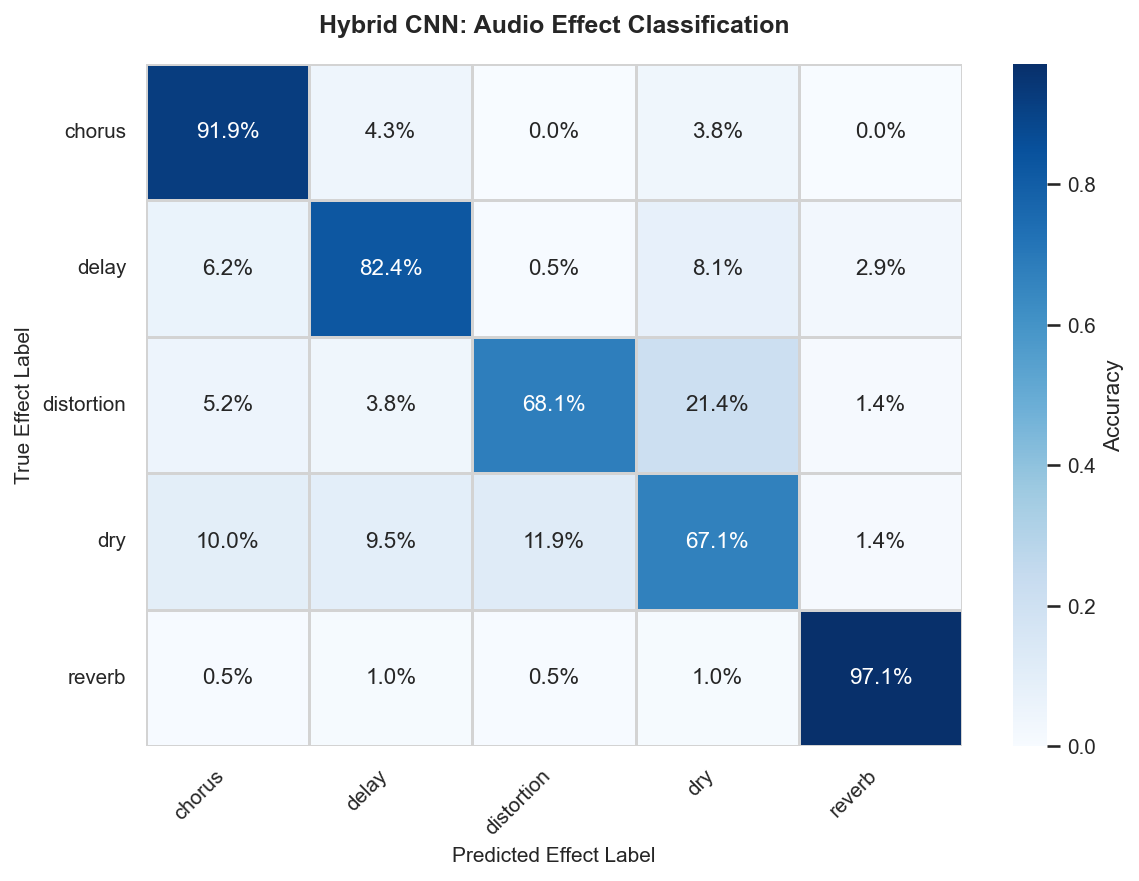

In [13]:

df = feature_df.copy()
le = LabelEncoder()
df['label'] = le.fit_transform(df['effect_applied'])
test_df = df[df['split'] == 'test']

# Initialization
model = HybridMelSpectrogramCNN(num_classes=len(le.classes_), aux_feature_dim=4)
# Trigger LazyLinear with exact shapes
model(torch.randn(1, 1, 128, 258), torch.randn(1, 4)) 

try:
    model.load_state_dict(torch.load("best_hybrid_cnn.pth", map_location="cpu"))
    print("Success: Weights loaded correctly.")

    test_loader = DataLoader(MelSpectrogramDataset(test_df), batch_size=32, shuffle=False)
    evaluate_and_plot(model, test_loader, le.classes_)
except Exception as e:
    print(f"Error: {e}")